In [1]:
import collections
import re
import sys
from pathlib import Path
# 把 deeplearning 目录加入模块搜索路径
d2l_dir = Path(r"C:\Users\abc\Documents\GitHub\vscodepractice\deeplearning")
sys.path.insert(0, str(d2l_dir))
import math
import numpy as np
import torch
from torch import nn
import d2l_local as d2l
import random

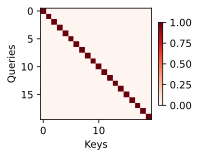

In [ ]:
#@save
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    d2l.use_svg_display()
    num_rows, num_cols, _, _ = matrices.shape
    # fig对应整张画布
    # axes对应每个子图的坐标轴对象，axes是一个二维数组，
    # axes[i][j]表示第i行第j列的子图的坐标轴对象
    # sharex=True, sharey=True意思是共享子图的横纵坐标轴，
    # squeeze=False意思是即使只有一行或一列子图，也保持axes为二维数组
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    # 
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            # matrix.detach()将matrix从计算图中分离出来，
            # 返回一个新的tensor，且不需要梯度计算
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            #只给最后一行的子图设置x轴标签
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            #只给第一列的子图设置y轴标签
            if j == 0:
                ax.set_ylabel(ylabel)
            # 如果提供了标题列表，就用第 j 个标题。
            # 这里按列取标题，因此同一列的子图会使用相同标题。
            if titles:
                ax.set_title(titles[j])
    #添加表示“颜色对应多大数值”的颜色条，shrink=0.6 将它的长度缩为默认长度的60%。
    fig.colorbar(pcm, ax=axes, shrink=0.6)

# torch.eye(10) 生成一个 10×10 的单位矩阵。reshape((1, 1, 10, 10)) 将其形状改为 (1, 1, 10, 10)，以便与多头注意力机制的输出形状一致。
# 如果将其看作注意力权重，那么相当于第一个query只关注第一个key，第二个query只关注第二个key，以此类推。也就是说，每个query都只关注与其对应的key。
attention_weights = torch.eye(20).reshape((1, 1, 20, 20))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

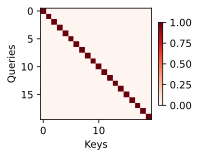

In [ ]:
#@save
def show_heatmaps1(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    d2l.use_svg_display()
    num_rows, num_cols, _, _ = matrices.shape
    # fig对应整张画布
    # axes对应每个子图的坐标轴对象，axes是一个二维数组，
    # axes[i][j]表示第i行第j列的子图的坐标轴对象
    # sharex=True, sharey=True意思是共享子图的横纵坐标轴，
    # squeeze=False意思是即使只有一行或一列子图，也保持axes为二维数组
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    # 索引写法：先取得编号，再用编号取对象
    for i in range(num_rows):
        for j in range(num_cols):
            ax = axes[i, j]
            matrix = matrices[i, j]
            # matrix.detach()将matrix从计算图中分离出来，
            # 返回一个新的tensor，且不需要梯度计算
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            #只给最后一行的子图设置x轴标签
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            #只给第一列的子图设置y轴标签
            if j == 0:
                ax.set_ylabel(ylabel)
            # 如果提供了标题列表，就用第 j 个标题。
            # 这里按列取标题，因此同一列的子图会使用相同标题。
            if titles:
                ax.set_title(titles[j])
    #添加表示“颜色对应多大数值”的颜色条，shrink=0.6 将它的长度缩为默认长度的60%。
    fig.colorbar(pcm, ax=axes, shrink=0.6)

# torch.eye(10) 生成一个 10×10 的单位矩阵。reshape((1, 1, 10, 10)) 将其形状改为 (1, 1, 10, 10)，以便与多头注意力机制的输出形状一致。
# 如果将其看作注意力权重，那么相当于第一个query只关注第一个key，第二个query只关注第二个key，以此类推。也就是说，每个query都只关注与其对应的key。
attention_weights = torch.eye(20).reshape((1, 1, 20, 20))
show_heatmaps1(attention_weights, xlabel='Keys', ylabel='Queries')